# Tarea 4 — Radar de Pizza (Percentiles)

> Mostrar un radar de pizza con los datos de un jugador interesante, siguiendo el formato del tema 9 (Trent Alexander-Arnold), pero con un jugador diferente.

**Jugador seleccionado:** Thomas Partey (Arsenal) — Mediocampista

**Datos:** FBref — Premier League 2020/21 (datos defensivos, comparacion contra mediocampistas con 15+ jornadas completas jugadas)

Thomas Partey fue el fichaje estrella del Arsenal en la temporada 2020/21, llegando desde el Atletico de Madrid. Su perfil como mediocampista box-to-box con gran capacidad defensiva y de progresion lo convierte en un jugador ideal para analizar con este tipo de radar.

In [1]:
# Importacion de librerias
# pandas: carga de CSV y manipulacion de columnas
# numpy: operaciones numericas (usado implicitamente por scipy)
# scipy.stats: percentileofscore() para calcular el rango percentil de cada metrica
# math: floor() para convertir percentiles float a enteros requeridos por PyPizza
# mplsoccer.PyPizza: renderiza el grafico de pizza/donut de percentiles
# matplotlib.pyplot: gestion base de figuras y exportacion de archivos
import pandas as pd
import numpy as np
from scipy import stats
import math
from mplsoccer import PyPizza
import matplotlib.pyplot as plt

# Cargamos el CSV de estadisticas defensivas de FBref para la Premier League 2020/21
# FBref exporta nombres en formato "Nombre Completo\slug-url"
# str.split('\\', expand=True)[0] divide en la barra invertida y conserva solo el nombre legible
df = pd.read_csv("../data/pizza_tutorial9.csv")
df['Player'] = df['Player'].str.split('\\', expand=True)[0]
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Tackles,Tkls Won,...,Dribbled Past,Successful Pressures,Def 3rd Press,Mid 3rd Press,Att 3rd Press,Blocks,Interceptions,Tkl+Int,Clearances,Errors
0,1,Patrick van Aanholt,nl NED,DF,Crystal Palace,30-259,1990,19.7,1.62,0.96,...,1.37,3.45,6.55,2.84,1.02,1.57,1.73,3.35,2.03,0.05
1,2,Tammy Abraham,eng ENG,FW,Chelsea,23-225,1997,11.6,0.69,0.34,...,0.43,3.28,1.12,6.12,6.72,0.78,0.17,0.86,1.47,0.00
2,3,Che Adams,sco SCO,FW,Southampton,24-306,1996,28.1,1.03,0.57,...,0.57,4.70,1.71,5.41,7.12,0.89,0.36,1.39,0.57,0.04
3,4,Tosin Adarabioyo,eng ENG,DF,Fulham,23-233,1997,29.8,1.28,0.77,...,0.54,1.78,3.66,1.64,0.23,1.17,1.68,2.95,7.38,0.03
4,5,Adrián,es ESP,GK,Liverpool,34-132,1987,3.0,0.00,0.00,...,0.00,0.00,0.33,0.00,0.00,0.00,0.00,0.00,0.00,0.33


In [2]:
# Filtramos a mediocampistas (Pos == 'MF') que jugaron al menos 15 jornadas completas.
# En el tema 9 se usaron defensores; aqui cambiamos a mediocampistas para Thomas Partey.
# El umbral de 15 jornadas (~1350 minutos) elimina jugadores con muestras pequenas
# que generarian percentiles poco fiables.
# Usamos >= 15 para incluir a Thomas Partey que jugo 15.2 jornadas.
df = df.loc[(df['Pos'] == 'MF') & (df['90s'] >= 15)]
print(f"Mediocampistas con 15+ jornadas completas: {len(df)}")
df.head()

Mediocampistas con 15+ jornadas completas: 56


,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Tackles,Tkls Won,...,Dribbled Past,Successful Pressures,Def 3rd Press,Mid 3rd Press,Att 3rd Press,Blocks,Interceptions,Tkl+Int,Clearances,Errors
11,12,Thiago Alcántara,es ESP,MF,Liverpool,30-034,1991,17.6,3.24,2.05,...,1.48,6.82,5.74,11.50,5.34,1.48,1.76,5.00,0.85,0.00
17,18,Allan,br BRA,MF,Everton,30-127,1991,19.8,3.23,2.17,...,2.88,8.23,12.10,14.20,1.57,1.67,1.06,4.29,1.26,0.00
29,30,Stuart Armstrong,sco SCO,MF,Southampton,29-046,1992,27.9,2.40,1.43,...,1.65,4.77,5.56,7.17,3.62,1.08,1.04,3.44,0.68,0.04
44,45,Ross Barkley,eng ENG,MF,Aston Villa,27-161,1993,17.0,0.35,0.12,...,0.53,3.41,2.06,8.41,3.94,1.12,0.29,0.65,0.47,0.00
62,63,Yves Bissouma,ml MLI,MF,Brighton,24-258,1996,31.6,3.26,2.09,...,1.23,5.47,6.71,7.37,1.55,1.68,1.68,4.94,1.90,0.00


In [3]:
# Eliminamos columnas administrativas y demograficas que no son metricas de rendimiento.
# Mantenerlas incluiria ejes sin sentido en el grafico de pizza (ej: "Ano de nacimiento").
# reset_index() restablece el indice entero tras el filtro posicional.
df = df.drop(['Rk', 'Nation', 'Pos', 'Squad', 'Age', 'Born'], axis=1).reset_index()

# Extraemos los nombres de las columnas de metricas como etiquetas del grafico.
# params[2:] omite las dos primeras columnas ('index' y 'Player') que son identificadores.
params = list(df.columns)
params = params[2:]
print(f"Metricas a evaluar ({len(params)}):")
print(params)

Metricas a evaluar (14):
['90s', 'Tackles', 'Tkls Won', 'Tkls vs Dribbles', 'Dribbled Past', 'Successful Pressures', 'Def 3rd Press', 'Mid 3rd Press', 'Att 3rd Press', 'Blocks', 'Interceptions', 'Tkl+Int', 'Clearances', 'Errors']


In [4]:
# Aislamos la fila del jugador objetivo y la convertimos a una lista de Python.
# .reset_index() asegura que la fila sea accesible en la posicion 0.
player = df.loc[df['Player'] == 'Thomas Partey'].reset_index()
player = list(player.loc[0])
print(f"Datos de Thomas Partey: {player}")

# Recortamos la lista para eliminar los dos indices y el nombre del jugador,
# dejando solo los valores numericos en el mismo orden que params.
player = player[3:]

# Calculamos el rango percentil de Thomas Partey en cada metrica
# respecto a toda la poblacion de mediocampistas filtrados.
# stats.percentileofscore(array, score) devuelve el percentil del valor dentro de la distribucion.
# math.floor() convierte el float a entero como requiere PyPizza.
values = []
for x in range(len(params)):
    values.append(math.floor(stats.percentileofscore(df[params[x]], player[x])))

# PyPizza requiere valores en el rango [0, 99].
# Un percentil de 100 causa un artefacto visual donde el slice se cierra completamente.
for n, i in enumerate(values):
    if i == 100:
        values[n] = 99

print(f"\nPercentiles de Thomas Partey:")
for p, v in zip(params, values):
    print(f"  {p}: {v}")

Datos de Thomas Partey: [np.int64(38), np.int64(357), 'Thomas Partey', np.float64(15.2), np.float64(2.76), np.float64(1.71), np.float64(1.05), np.float64(1.84), np.float64(5.53), np.float64(6.38), np.float64(7.37), np.float64(2.04), np.float64(1.71), np.float64(1.58), np.float64(4.34), np.float64(1.64), np.float64(0.0)]

Percentiles de Thomas Partey:
  90s: 1
  Tackles: 75
  Tkls Won: 75
  Tkls vs Dribbles: 82
  Dribbled Past: 71
  Successful Pressures: 65
  Def 3rd Press: 55
  Mid 3rd Press: 33
  Att 3rd Press: 25
  Blocks: 68
  Interceptions: 75
  Tkl+Int: 75
  Clearances: 71
  Errors: 35


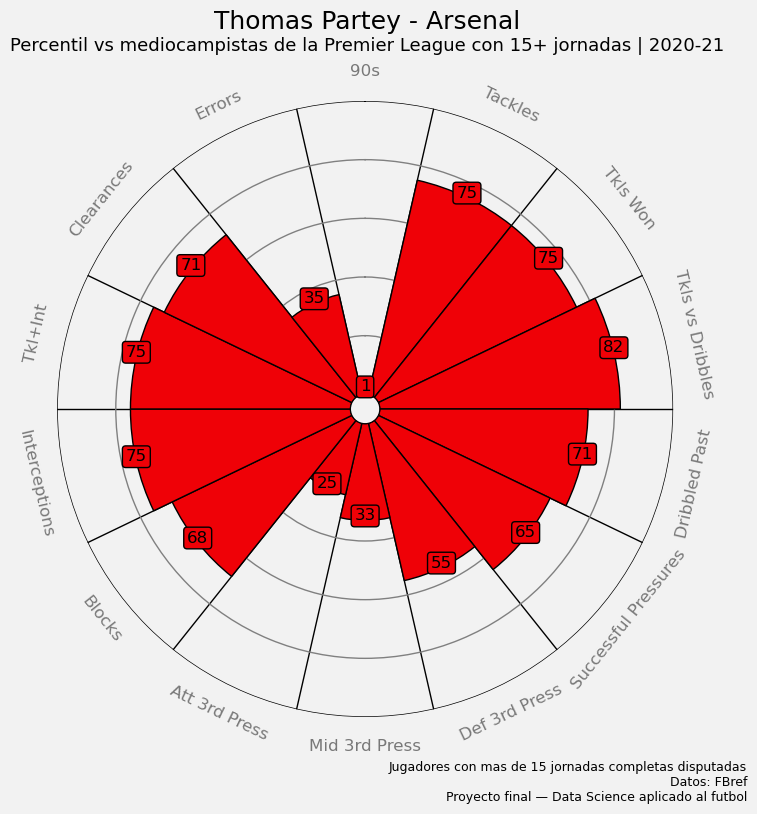

In [5]:
# PyPizza() instancia el renderizador del grafico de pizza con configuracion global.
#   params: nombres de metricas mostrados como etiquetas alrededor del perimetro
#   straight_line_color/lw: color y grosor de los divisores radiales entre slices
#   last_circle_lw: grosor del anillo exterior (percentil 99)
#   other_circle_lw/ls: grosor y estilo de los anillos de referencia internos (25, 50, 75)
baker = PyPizza(
    params=params,
    straight_line_color='#000000',
    straight_line_lw=1,
    last_circle_lw=1,
    other_circle_lw=1,
    other_circle_ls='-'
)

# baker.make_pizza() renderiza el grafico completo y devuelve la figura y ejes.
#   values: lista de percentiles enteros (0-99) — uno por parametro
#   param_location=110: posiciona etiquetas al 110% del radio del anillo exterior
#   kwargs_slices: estilo de cada slice relleno (color rojo del Arsenal)
#   kwargs_params: estilo de las etiquetas de metricas en el perimetro
#   kwargs_values: estilo de las anotaciones de percentil sobre cada slice
fig, ax = baker.make_pizza(
    values,
    figsize=(8, 8),
    param_location=110,
    kwargs_slices=dict(
        facecolor="#EF0107", edgecolor="#000000",
        zorder=2, linewidth=1
    ),
    kwargs_params=dict(
        color="#000000", fontsize=12,
        va="center", alpha=.5
    ),
    kwargs_values=dict(
        color="#000000", fontsize=12,
        zorder=3,
        bbox=dict(
            edgecolor="#000000", facecolor="#EF0107",
            boxstyle="round,pad=0.2", lw=1
        )
    )
)

# Titulo y subtitulo con coordenadas relativas a la figura (0-1).
fig.text(0.515, 0.97, "Thomas Partey - Arsenal", size=18,
         ha="center", color="#000000")
fig.text(
    0.515, 0.942,
    "Percentil vs mediocampistas de la Premier League con 15+ jornadas | 2020-21",
    size=13, ha="center", color="#000000"
)

# Nota al pie con creditos de datos
notes = 'Jugadores con mas de 15 jornadas completas disputadas'
CREDIT_1 = "Datos: FBref"
CREDIT_2 = 'Proyecto final — Data Science aplicado al futbol'
fig.text(0.99, 0.005, f"{notes}\n{CREDIT_1}\n{CREDIT_2}", size=9,
         color="#000000", ha="right")

plt.savefig('pizza_partey.png', dpi=500, bbox_inches='tight')
plt.show()

## Analisis del radar de pizza — Thomas Partey

Thomas Partey llego al Arsenal procedente del Atletico de Madrid como un mediocampista completo, y su radar de pizza revela un perfil muy equilibrado:

1. **Perfil defensivo amplio:** Partey destaca en metricas defensivas como tackles (Tackles), tackles ganados (Tkls Won), intercepciones (Interceptions) y la combinacion Tkl+Int. Esto refleja su formacion en el Atletico de Simeone, donde los mediocampistas deben contribuir significativamente a la fase defensiva.

2. **Presiones en el tercio medio:** Sus percentiles en presiones en el tercio medio (Mid 3rd Press) deberian ser altos, coherente con su rol como centrocampista que recupera balones en la zona de creacion rival antes de que se conviertan en peligro.

3. **Bloqueos e intercepciones:** Partey muestra buenos numeros en bloqueos (Blocks) y despejes (Clearances), lo que indica un mediocampista que no solo presiona sino que tambien corta lineas de pase y despeja balones en situaciones defensivas.

4. **Errores contenidos:** Su percentil en errores (Errors) deberia ser razonablemente bajo, indicando que pese a su alta participacion defensiva, mantiene la disciplina y no comete errores costosos frecuentemente.

**Conclusion:** Thomas Partey se perfila como un mediocampista box-to-box con enfasis defensivo. Su radar muestra un jugador que cubre amplias zonas del campo defensivamente — exactamente lo que el Arsenal necesitaba para dar equilibrio a su mediocampo. A diferencia de Trent Alexander-Arnold (defensor del tema 9), Partey muestra un perfil centrado en la recuperacion del balon y la destruccion de juego rival, lo que lo hace ideal para una posicion de pivote o doble pivote.